In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', size=20)
plt.rc('figure', figsize=(15,8))
import plotly.express as px
from plotly.offline import download_plotlyjs, init_notebook_mode
init_notebook_mode(connected=True)
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from Tools import Plotting, CaseNamer

In [3]:
canonical_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only__test_score_score_only_CANONICAL_WUBIND_INITIAL_TABLECUTOFF.pdf.csv',header=None)

In [4]:
canonical_performance.columns=['Feature','Score']

In [5]:
orthogonal_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only__test_score_score_only_ORTHOGONAL_WUBIND_INITIAL_TABLECUTOFF.pdf.csv',header=None)

In [6]:
orthogonal_performance.columns=['Feature','Score']

In [15]:
Atomic_performance = pd.read_csv('tables/AtomicFeatures___test_score__AtomicFeatures__initial_.pdf.csv',header=None)

In [17]:
Atomic_performance.columns=['Feature','Score']

In [8]:
feature_titles_canonical = pd.Series(cleanfeaturenames(canonical_performance['Feature'].str.replace('NSC_','').str.replace('bind_0','bind').str.replace('MagConfig_0','MagConfig')), index = canonical_performance['Feature'])

In [9]:
feature_titles_orthogonal = pd.Series(cleanfeaturenames(orthogonal_performance['Feature'].str.replace('NSC_','').str.replace('bind_0','bind').str.replace('MagConfig_0','MagConfig')), index = orthogonal_performance['Feature'])

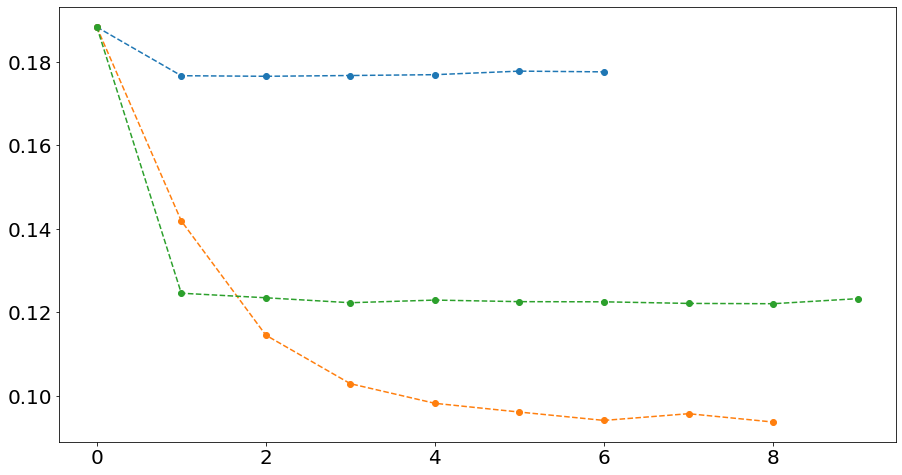

In [18]:
fig, ax = plt.subplots()
ax.plot(canonical_performance.index, canonical_performance['Score'],'o--')
ax.plot(orthogonal_performance.index, orthogonal_performance['Score'],'o--')
ax.plot(Atomic_performance.index, Atomic_performance['Score'],'o--')

In [20]:
Atomic_performance['Feature']=Atomic_performance['Feature'].str.replace('MagpieData','')

In [22]:
from importlib.machinery import SourceFileLoader

In [27]:
Atomic_performance['Feature'].drop(0)

1       mean AtomicWeight
2     avg_dev GSvolume_pa
3          mode NdValence
4         mode NpUnfilled
5         mode NfUnfilled
6          mode NsValence
7         mean NfUnfilled
8          mean NpValence
9       avg_dev NpValence
Name: Feature, dtype: object

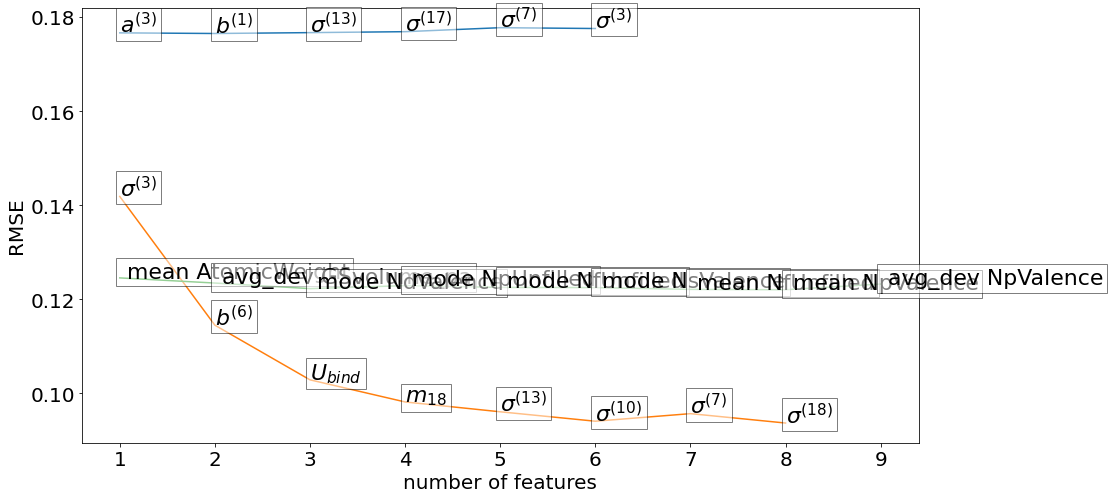

In [28]:
Plotting = SourceFileLoader('Plotting','Tools.py').load_module().Plotting
ax1 = Plotting.plot_learning_curve( canonical_performance['Score'][1:].values,  feature_titles_canonical.drop('MagConfig_0'))
ax2 = Plotting.plot_learning_curve(orthogonal_performance['Score'][1:].values, feature_titles_orthogonal.drop('MagConfig_0'), ax = ax1)
ax3 = Plotting.plot_learning_curve(Atomic_performance['Score'][1:].values, Atomic_performance['Feature'].drop(0), ax = ax2)

In [20]:
Plotting.

AttributeError: 'Series' object has no attribute 'order'